## Question 1:

   car_ID  symboling                   CarName fueltype aspiration doornumber  \
0       1          3        alfa-romero giulia      gas        std        two   
1       2          3       alfa-romero stelvio      gas        std        two   
2       3          1  alfa-romero Quadrifoglio      gas        std        two   
3       4          2               audi 100 ls      gas        std       four   
4       5          2                audi 100ls      gas        std       four   

       carbody drivewheel enginelocation  wheelbase  ...  enginesize  \
0  convertible        rwd          front       88.6  ...         130   
1  convertible        rwd          front       88.6  ...         130   
2    hatchback        rwd          front       94.5  ...         152   
3        sedan        fwd          front       99.8  ...         109   
4        sedan        4wd          front       99.4  ...         136   

   fuelsystem  boreratio  stroke compressionratio horsepower  peakrpm citympg  \

C:\Users\rashi\AppData\Local\Temp\ipykernel_17644\2587738314.py:18: FutureWarning: 

`shade` is now deprecated in favor of `fill`; setting `fill=True`.
This will become an error in seaborn v0.14.0; please update your code.

  sns.kdeplot(df['price'], shade=True, color='purple')


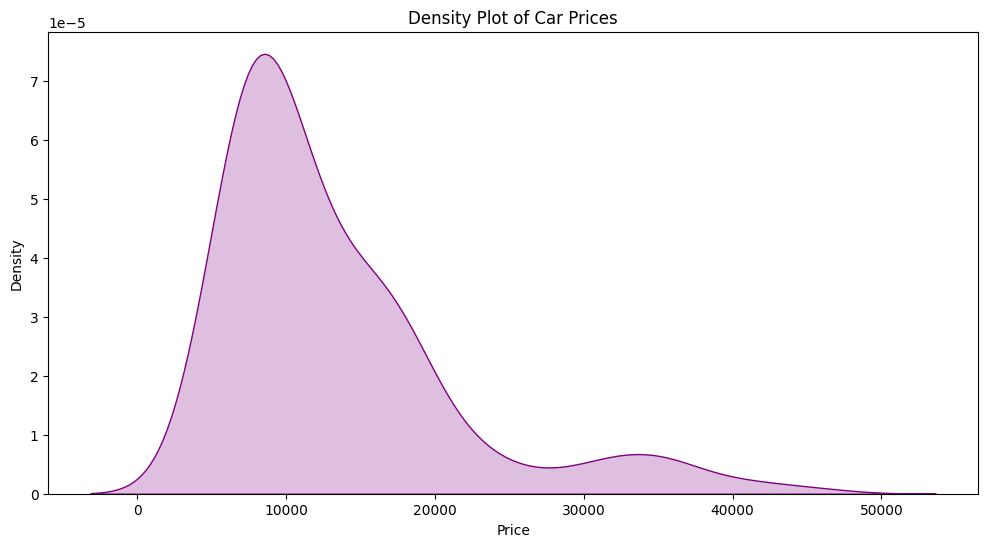

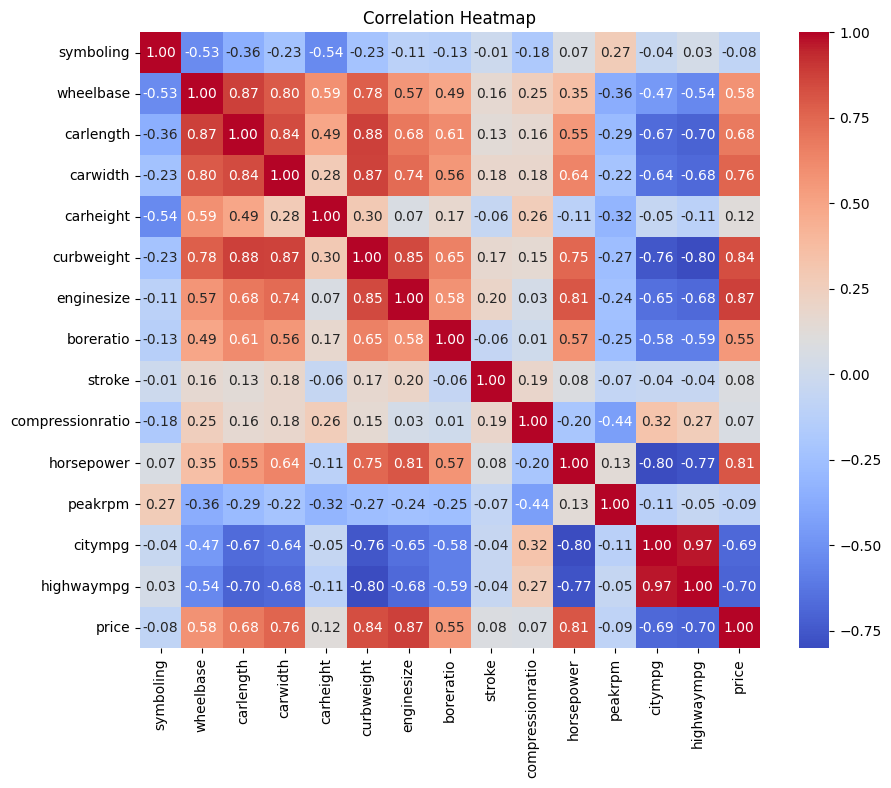

TRAIN Results -> MAE: 1943.65, MSE: 6857222.92, RMSE: 2618.63, R²: 0.9008
TEST Results -> MAE: 1918.27, MSE: 6367006.16, RMSE: 2523.29, R²: 0.8100
             Feature  Coefficient   Importance
14        enginesize  3312.590309  3312.590309
9           carwidth  1435.077169  1435.077169
6     enginelocation  1394.121530  1394.121530
11        curbweight  1381.606089  1381.606089
23             brand -1307.945502  1307.945502
19        horsepower  1304.637671  1304.637671
18  compressionratio  1301.188148  1301.188148
22        highwaympg  1194.640021  1194.640021
1           fueltype  1021.646416  1021.646416
4            carbody  -964.441843   964.441843


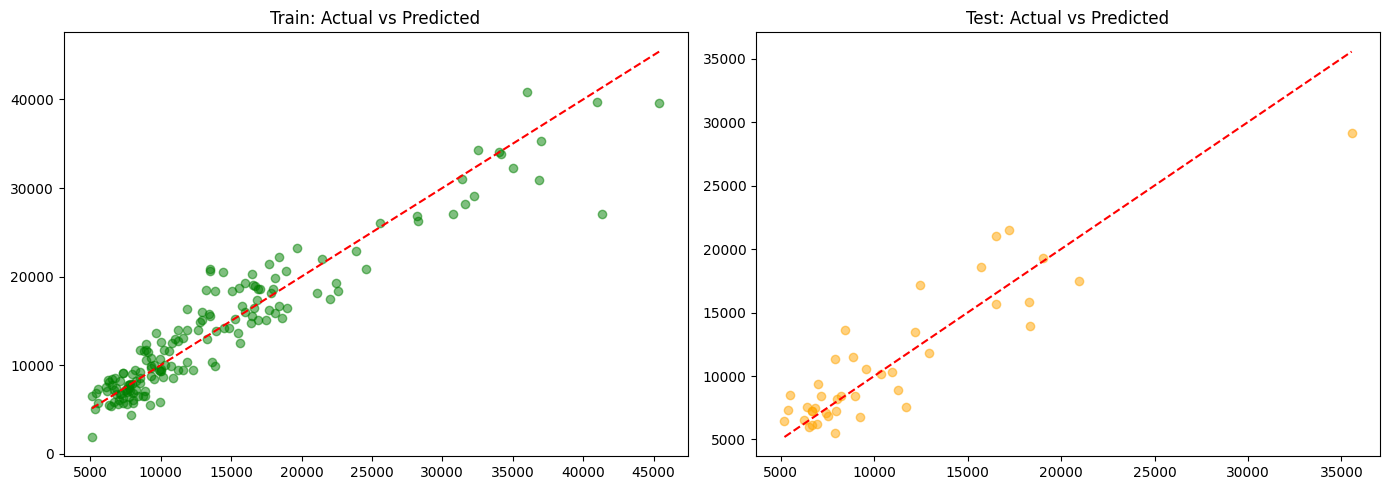

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

df = pd.read_csv("CarPrice_Assignment.csv")

print(df.head())
print(df.info())
print(df.describe())
print(df.isnull().sum())

plt.figure(figsize=(12, 6))
sns.kdeplot(df['price'], shade=True, color='purple')
plt.title('Density Plot of Car Prices')
plt.xlabel('Price')
plt.show()

numeric_features = df.select_dtypes(include=[np.number]).columns.tolist()
numeric_features.remove('car_ID')
plt.figure(figsize=(10, 8))
sns.heatmap(df[numeric_features].corr(), annot=True, fmt=".2f", cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()

categorical_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel',
                    'enginelocation', 'enginetype', 'cylindernumber', 'fuelsystem']

df['brand'] = df['CarName'].str.split().str[0]

categorical_cols.append('brand')
le_dict = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    le_dict[col] = le

X = df.drop(columns=['car_ID', 'CarName', 'price'])
y = df['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)

y_train_pred = lr.predict(X_train_scaled)
y_test_pred = lr.predict(X_test_scaled)

def evaluate(y_true, y_pred, name):
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_true, y_pred)
    print(f"{name} Results -> MAE: {mae:.2f}, MSE: {mse:.2f}, RMSE: {rmse:.2f}, R²: {r2:.4f}")

evaluate(y_train, y_train_pred, "TRAIN")
evaluate(y_test, y_test_pred, "TEST")

coef_df = pd.DataFrame({'Feature': X.columns, 'Coefficient': lr.coef_})
coef_df['Importance'] = abs(coef_df['Coefficient'])
coef_df = coef_df.sort_values(by='Importance', ascending=False)
print(coef_df.head(10))

plt.figure(figsize=(14,5))
plt.subplot(1,2,1)
plt.scatter(y_train, y_train_pred, alpha=0.5, color='green')
plt.plot([y_train.min(), y_train.max()], [y_train.min(), y_train.max()], 'r--')
plt.title('Train: Actual vs Predicted')

plt.subplot(1,2,2)
plt.scatter(y_test, y_test_pred, alpha=0.5, color='orange')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.title('Test: Actual vs Predicted')

plt.tight_layout()
plt.show()


## Question 2:

   Fan  Refrigerator  AirConditioner  Television  Monitor  MotorPump  Month  \
0   16          23.0             2.0         6.0      1.0          0     10   
1   19          22.0             2.0         3.0      1.0          0      5   
2    7          20.0             2.0         6.0      7.0          0      7   
3    7          22.0             3.0        21.0      1.0          0      6   
4   11          23.0             2.0        11.0      1.0          0      2   

        City                                    Company  MonthlyHours  \
0  Hyderabad                    Tata Power Company Ltd.           384   
1   Vadodara                                       NHPC           488   
2     Shimla                            Jyoti Structure           416   
3     Mumbai                            Power Grid Corp           475   
4     Mumbai  Ratnagiri Gas and Power Pvt. Ltd. (RGPPL)           457   

   TariffRate  ElectricityBill  
0         8.4           3225.6  
1         7.8       

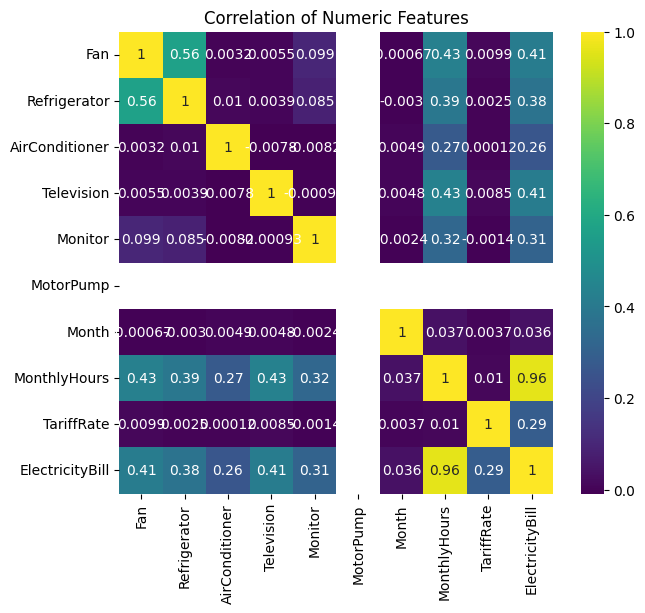

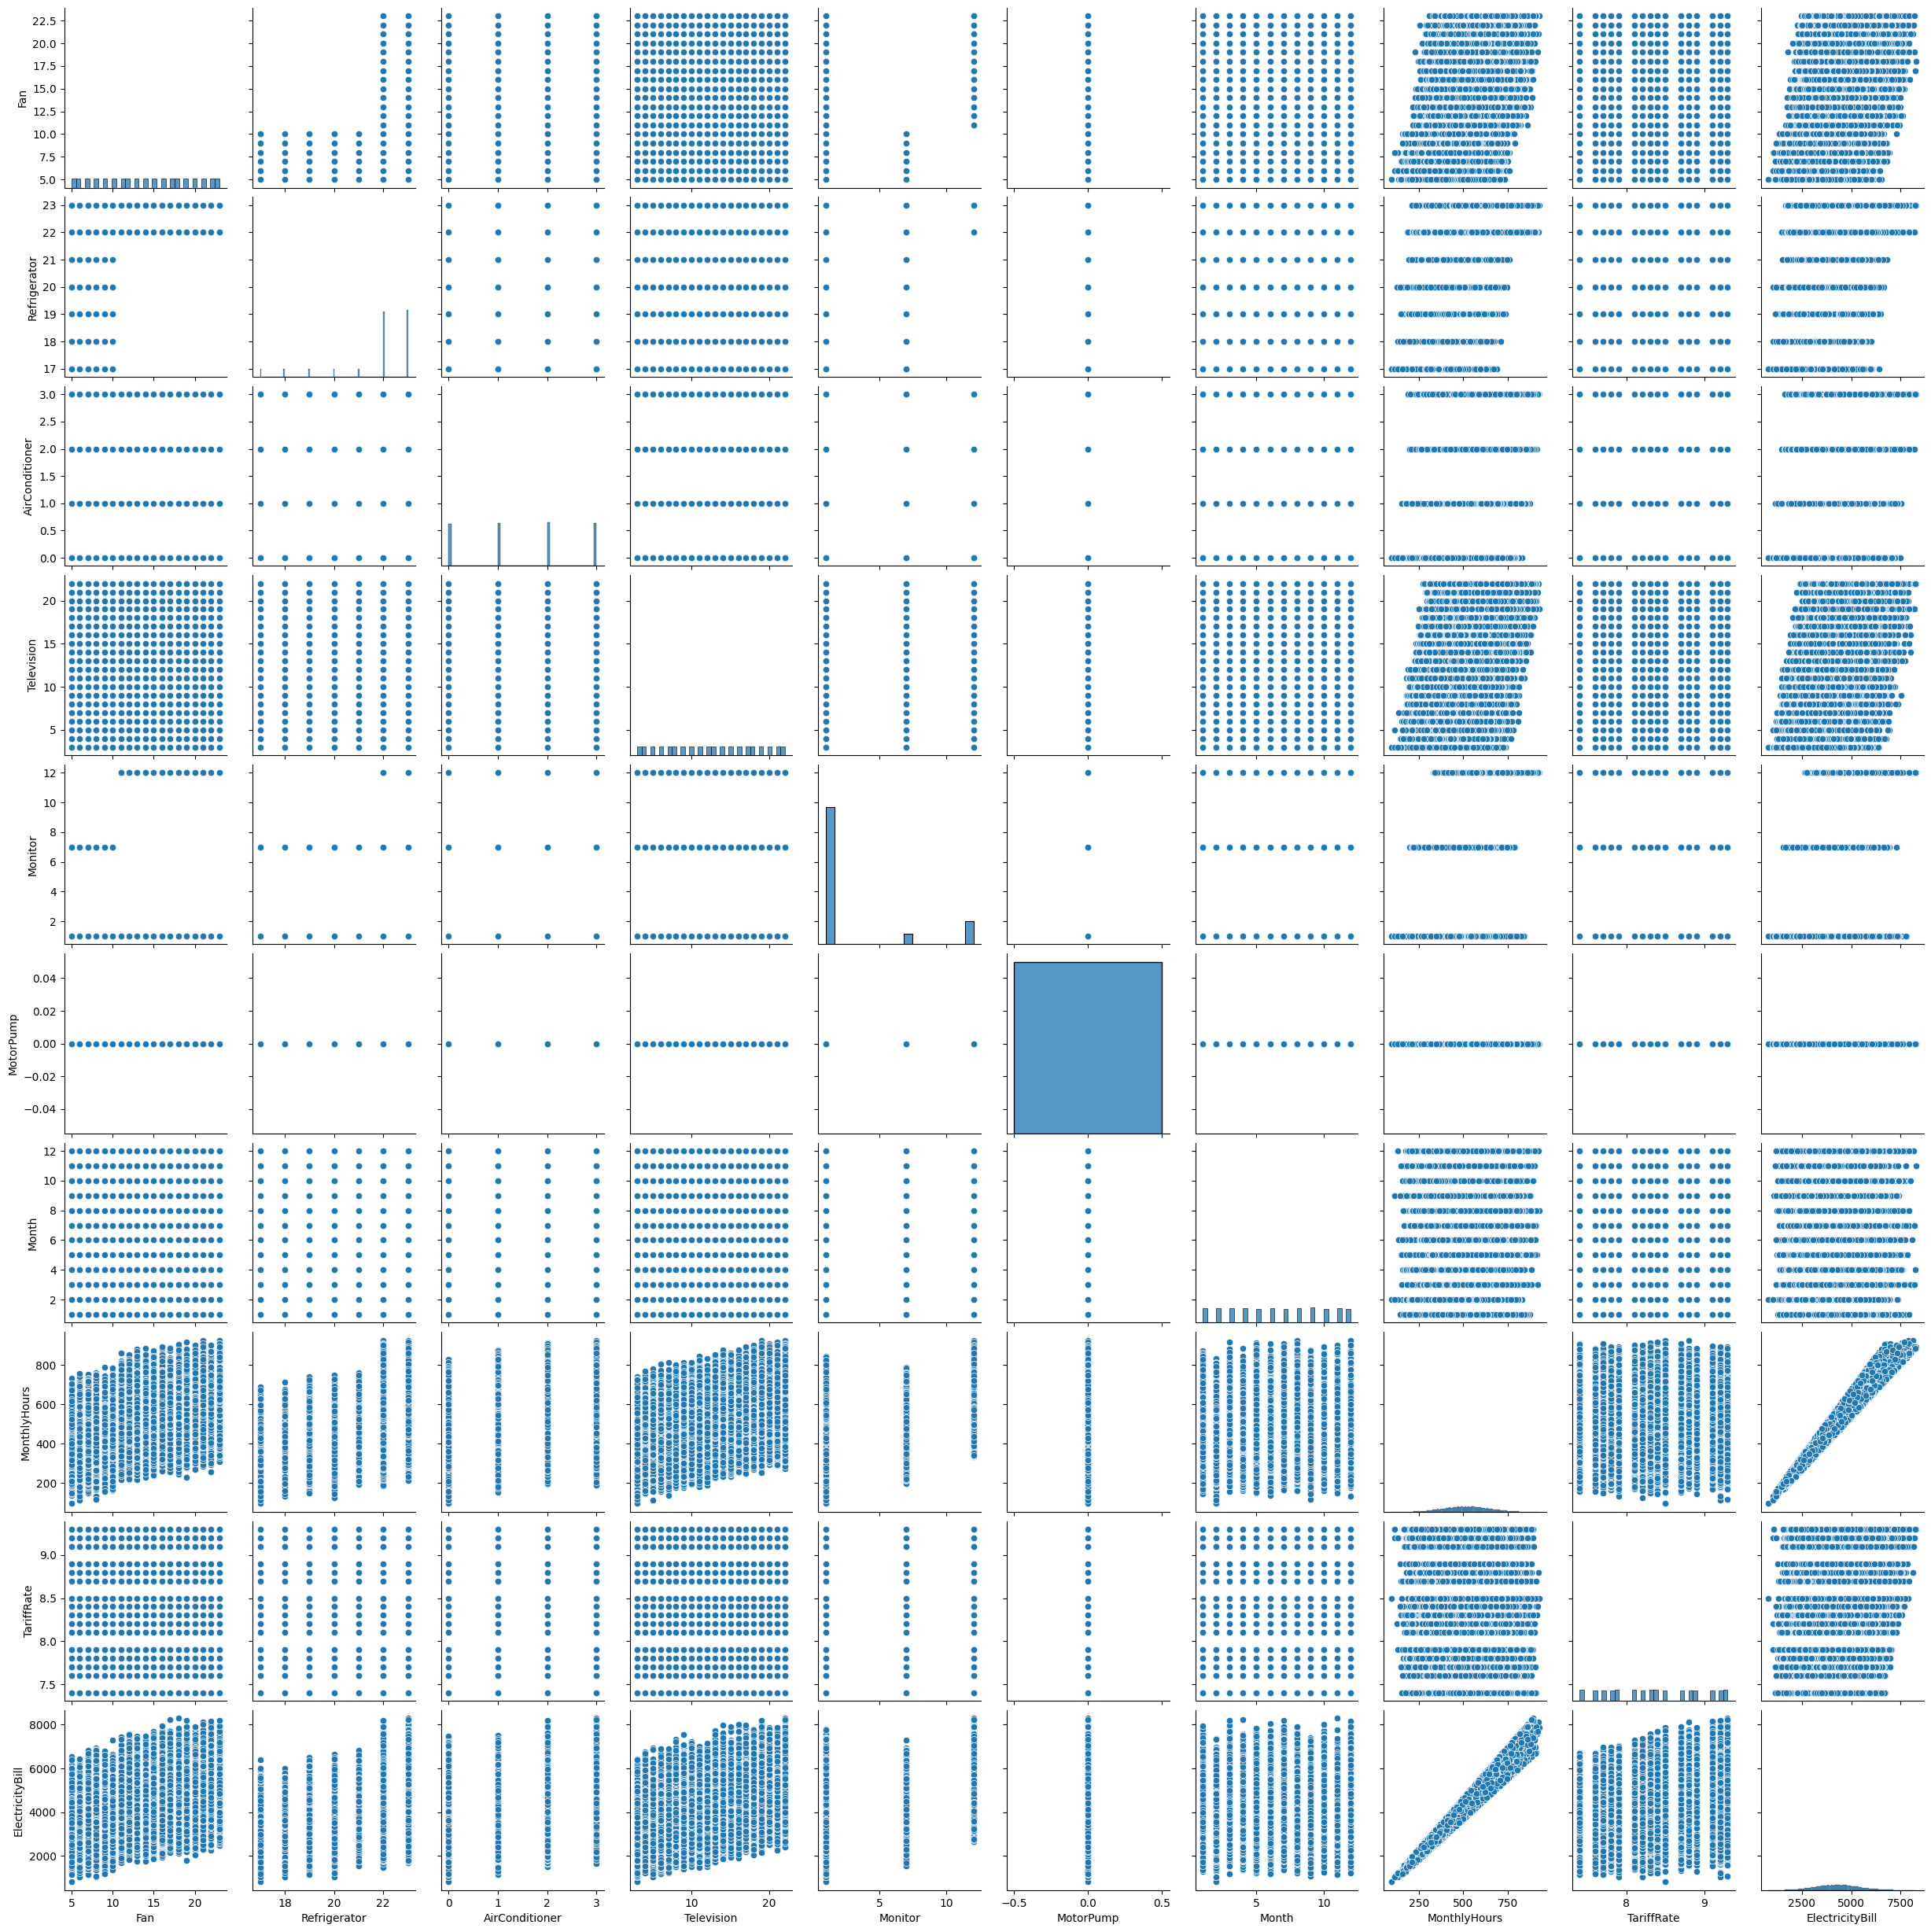

R² Score: 0.9956403827920036
Mean Squared Error: 4975.188391640067


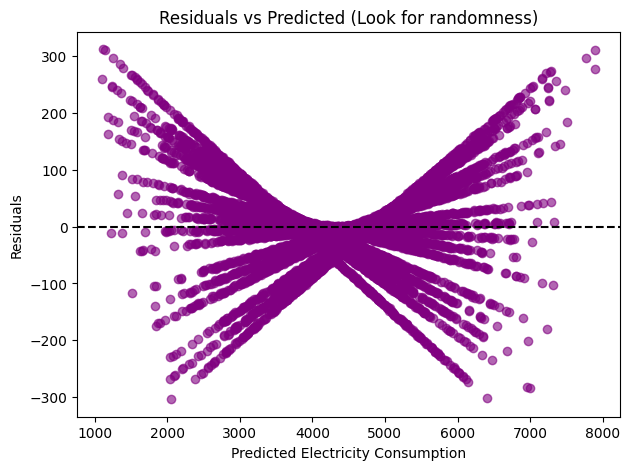

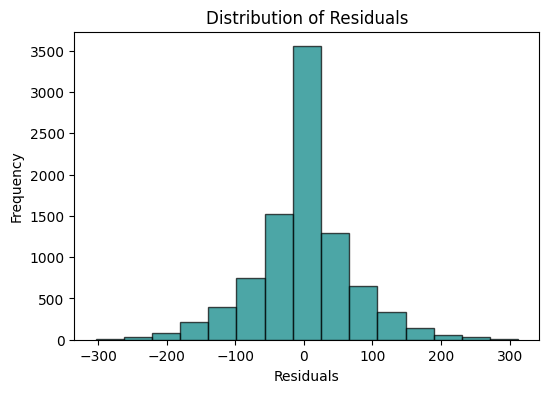

In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error

df = pd.read_csv("electricity_bill_dataset.csv")

print(df.head())

numeric_cols = df.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(7,6))
sns.heatmap(numeric_cols.corr(), annot=True, cmap='viridis')
plt.title("Correlation of Numeric Features")
plt.show()

sns.pairplot(numeric_cols)
plt.show()

X = numeric_cols.drop(columns=['ElectricityBill'], errors='ignore')
y = numeric_cols['ElectricityBill']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

lr = LinearRegression()
lr.fit(X_train, y_train)

y_pred = lr.predict(X_test)

print("R² Score:", r2_score(y_test, y_pred))
print("Mean Squared Error:", mean_squared_error(y_test, y_pred))

residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6, color='purple')
plt.axhline(0, color='black', linestyle='--')
plt.xlabel("Predicted Electricity Consumption")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted (Look for randomness)")
plt.show()

plt.figure(figsize=(6,4))
plt.hist(residuals, bins=15, color='teal', edgecolor='black', alpha=0.7)
plt.title("Distribution of Residuals")
plt.xlabel("Residuals")
plt.ylabel("Frequency")
plt.show()


## Question 3:
### Linear Regression
#### Linear regression assumes a linear relationship between the input features and the output variable. It also expects that the errors have constant variance (homoscedasticity), follow a normal distribution, and that each observation is independent. Additionally, the features should not be highly correlated with each other.

### Decision Tree Classifier
#### Decision trees do not require any specific assumptions about the data. They work by splitting the dataset into subsets based on feature values and can handle both numerical and categorical features effectively.

### K-Nearest Neighbors (KNN)
#### KNN assumes that data points that are close to each other are likely to belong to the same class. It also presumes that all features contribute equally, so feature scaling or normalization is important for optimal performance.

### Support Vector Machine (SVM)
#### SVM assumes that the classes can be separated by a hyperplane, meaning the data is linearly separable or approximately so. It also requires the data to be properly scaled, as large feature values can disproportionately influence the separation. SVM performs best when classes are distinct and well-separated.

### Random Forest Classifier
#### Random Forest makes minimal assumptions about the data. It is based on the principle that aggregating multiple decision trees leads to better predictive accuracy and generalization than relying on a single tree.